# ResNet50 Training Pipeline

Fine-tunes a pretrained ResNet50 backbone for 3-class chest X-ray classification: `NORMAL`, `BACTERIAL_PNEUMONIA`, and `VIRAL_PNEUMONIA`.

## Training strategy

| Phase | Epochs | Layers trained | Learning rate |
|---|---|---|---|
| 1 — Head warm-up | 1–3 | Head only (`Dropout → Linear`) | `1e-4` |
| 2 — Fine-tuning | 4+ | Head + `layer3` + `layer4` | `5e-6` |

Freezing the backbone for the first 3 epochs prevents the randomly-initialised head from corrupting pretrained features before it has stable gradients. Unfreezing only the two deepest residual stages (`layer3`, `layer4`) in Phase 2 fine-tunes the high-level semantic features while keeping low-level edge detectors (`layer1`, `layer2`) fixed.

## Key design decisions
- **Class-weighted loss**: weights inversely proportional to class frequency to handle the imbalance between BACTERIAL (largest) and VIRAL (smallest) classes
- **Label smoothing (0.1)**: softens targets to prevent overconfidence, which helps on the hard VIRAL class
- **Early stopping (patience=4)**: halts training when validation loss stops improving for 4 consecutive epochs
- **GradScaler**: enables mixed-precision training; no-ops gracefully on CPU

## Outputs
- `resnet50_pneumonia.pth` — best model weights (lowest validation loss)
- `classes.json` — class index-to-label mapping used by the Streamlit inference app

In [2]:
# Install this once
!pip install import-ipynb
!pip install import-ipynb scikit-learn

## DataLoader Import

Imports the cleaned datasets and preprocessing transforms from `Preprocessing_Pipeline.ipynb`. This gives us:
- `prep.train_dataset` / `prep.val_dataset` / `prep.test_dataset` — `ImageFolder` datasets after autoencoder-based outlier removal
- `prep.train_dataset.classes` — ordered class name list used to configure the model output layer

The full preprocessing pipeline (CLAHE, noise reduction, normalisation, augmentations) is already embedded in each dataset object. No additional transforms are applied here.

Cleaning datasets using autoencoder...

Processing class 0...


Class 0 Epoch 1, Total Loss: 31.8920


Class 0 Epoch 2, Total Loss: 19.4009


Class 0 Epoch 3, Total Loss: 17.8352


Class 0: removed 127 samples

Processing class 1...


...

Class 1: removed 8 samples

Processing class 2...


Class 2 Epoch 1, Total Loss: 4.0941


Class 2 Epoch 2, Total Loss: 4.0019


Class 2: removed 5 samples

Balancing train dataset...
Before balancing: {np.int64(0): np.int64(2403), np.int64(1): np.int64(1273), np.int64(2): np.int64(1277)}
After balancing: {np.int64(0): np.int64(1273), np.int64(1): np.int64(1273), np.int64(2): np.int64(1273)}
Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 3819
Validation size: 186
Test size: 604


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0336821].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0815775].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0855688].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0855688].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0256994].


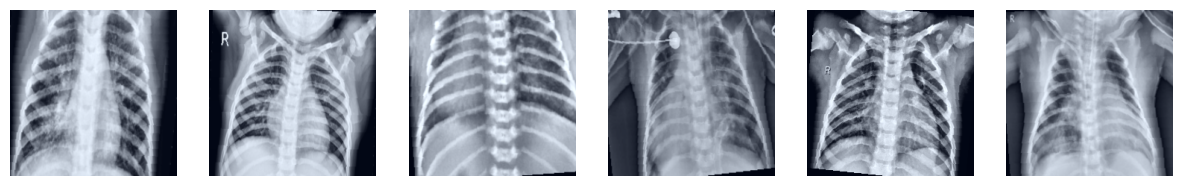

🔹 Train Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 1273 (33.33%)
NORMAL: 1273 (33.33%)
VIRAL_PNEUMONIA: 1273 (33.33%)

🔹 Test Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 234 (38.74%)
NORMAL: 227 (37.58%)
VIRAL_PNEUMONIA: 143 (23.68%)
🔹 Validation Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 62 (33.33%)
NORMAL: 62 (33.33%)
VIRAL_PNEUMONIA: 62 (33.33%)


In [3]:
import import_ipynb
import Preprocessing_Pipeline as prep

In [4]:
import copy
import json
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import models

from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [6]:
train_loader = DataLoader(prep.train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(prep.val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(prep.test_dataset, batch_size=32, shuffle=False)

NUM_CLASSES = len(prep.train_dataset.classes)

## ResNet50 Architecture

ResNet50 is a 50-layer residual network (~25M parameters). Its core innovation is **skip connections**: each residual block adds its input directly to its output, allowing gradients to flow backwards without vanishing. This makes it possible to train deep networks effectively on relatively small datasets.

The standard ImageNet classification head (`fc: Linear(2048 → 1000)`) is replaced with:
```
Dropout(p=0.5) → Linear(2048 → num_classes)
```
Dropout before the final layer provides regularisation at the boundary between the pretrained backbone and the new task-specific head.

In [7]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),   # Helps reduce variance / overfitting
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

model = model.to(device)

### Class Weighting

Computes inverse-frequency weights for each class: `weight[i] = total_samples / count[i]`. This means errors on the small `VIRAL_PNEUMONIA` class are penalised proportionally more than errors on the larger `BACTERIAL_PNEUMONIA` class. The weights are passed directly to `CrossEntropyLoss`, making the loss surface reflect clinical priority rather than dataset frequency.

In [8]:
counts = Counter(prep.train_dataset.targets)
total = sum(counts.values())
class_weights = [
    total / counts[i]
    for i in range(len(counts))
]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

## Training Configuration

| Parameter | Value | Rationale |
|---|---|---|
| Loss function | `CrossEntropyLoss` (weighted) | Class weights inversely proportional to sample count; penalises minority-class errors more heavily |
| Label smoothing | `0.1` | Softens one-hot targets to prevent overconfidence; helps on the hard VIRAL class |
| Optimizer | `Adam` | Adaptive per-parameter learning rates; robust without extensive LR tuning |
| Head LR (Phase 1) | `1e-4` | Fast convergence for the randomly-initialised head |
| Fine-tune LR (Phase 2) | `5e-6` | Low enough to nudge pretrained weights without overwriting them |
| Weight decay | `1e-4` | L2 regularisation |
| LR scheduler | `ReduceLROnPlateau` | Multiplies LR by 0.3 after 2 epochs without val loss improvement |
| Max epochs | `20` | Upper bound; early stopping typically triggers earlier |
| Freeze epochs | `3` | Epochs before backbone unfreezing |
| Early stop patience | `4` | Epochs to wait before halting training |
| Gradient clipping | `2.0` | Caps global gradient norm to prevent destructive updates from bad batches |

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.3)

EPOCHS = 20
PATIENCE = 4

best_val_loss = float('inf')
epochs_no_improve = 0

best_model_weights = copy.deepcopy(model.state_dict())

use_amp = torch.cuda.is_available()

scaler = torch.cuda.amp.GradScaler(
    enabled=use_amp
)

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

C:\Users\noora\AppData\Local\Temp\ipykernel_17500\3241202300.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


## Training Loop

`train_one_epoch` runs one full pass over the training set. Key implementation details:

- **Mixed precision** (`torch.cuda.amp.autocast`): forward pass computes in float16 where safe, reducing GPU memory and increasing throughput. `GradScaler` rescales gradients back to float32 before the optimizer step to prevent underflow
- **Gradient clipping** (`clip_grad_norm_=2.0`): caps the global L2 norm of all gradients, preventing a single bad batch from causing a destructive parameter update
- Returns average batch loss and per-epoch accuracy for tracking

In [10]:
def train_one_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            2.0
        )

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    return (
        total_loss / len(loader),
        correct / total
    )


## Evaluation Loop

`evaluate` runs a full pass over a dataloader under `torch.no_grad()`, which disables gradient computation and approximately halves memory usage. This function is used identically for both validation (after each training epoch) and final test evaluation, ensuring both are computed the same way.

In [11]:
def evaluate(model, loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        correct / total,
        np.array(all_probs),
        np.array(all_preds),
        np.array(all_labels)
    )

## Main Training Loop

Runs the full training cycle with two-phase fine-tuning, live loss plotting, and early stopping:

1. **Epochs 1–`FREEZE_EPOCHS`**: only the classification head is trained; backbone is frozen
2. **At epoch `FREEZE_EPOCHS`**: upper backbone layers are unfrozen and the optimizer is rebuilt at a lower learning rate to fine-tune pretrained weights gently
3. **Each epoch**: train → validate → step the LR scheduler → check early stopping → update live loss plot
4. **Best model checkpointing**: the state dict is saved in memory whenever validation loss reaches a new minimum. If early stopping triggers, training ends with the best weights already captured and ready to restore

In [12]:
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, _, _, _ = evaluate(
        model,
        val_loader
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    gap = train_acc - val_acc

    print(f"Generalization Gap: {gap:.4f}")
    if gap > 0.10:
        print("⚠️ Possible Overfitting (High Variance)")
    elif gap < 0.02 and val_acc < 0.75:
        print("⚠️ Possible Underfitting (High Bias)")
    else:
        print("✅ Good Bias-Variance Tradeoff")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(
            model.state_dict()
        )
        print("✅ Best model updated")
    else:
        epochs_no_improve += 1
        print(
            f"⚠️ No improvement for "
            f"{epochs_no_improve} epochs"
        )
    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered")
        break


Epoch 1/20


Training:   0%|          | 0/120 [00:00<?, ?it/s]C:\Users\noora\AppData\Local\Temp\ipykernel_17500\334661606.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
                                                                       

Train Loss: 1.0109 | Train Acc: 0.5261
Val Loss: 0.8798 | Val Acc: 0.7258
Generalization Gap: -0.1998
⚠️ Possible Underfitting (High Bias)
✅ Best model updated

Epoch 2/20


Train Loss: 0.7386 | Train Acc: 0.7206
Val Loss: 0.6215 | Val Acc: 0.8065
Generalization Gap: -0.0858
✅ Good Bias-Variance Tradeoff
✅ Best model updated

Epoch 3/20


Train Loss: 0.6358 | Train Acc: 0.7505
Val Loss: 0.5493 | Val Acc: 0.8172
Generalization Gap: -0.0667
✅ Good Bias-Variance Tradeoff
✅ Best model updated

Epoch 4/20


...

Train Loss: 0.4016 | Train Acc: 0.8874
Val Loss: 0.3829 | Val Acc: 0.9140
Generalization Gap: -0.0266
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 1 epochs

Epoch 17/20


Train Loss: 0.3791 | Train Acc: 0.8997
Val Loss: 0.3696 | Val Acc: 0.8925
Generalization Gap: 0.0072
✅ Good Bias-Variance Tradeoff
✅ Best model updated

Epoch 18/20


Train Loss: 0.3751 | Train Acc: 0.8987
Val Loss: 0.3899 | Val Acc: 0.9086
Generalization Gap: -0.0099
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 1 epochs

Epoch 19/20


Train Loss: 0.3686 | Train Acc: 0.9068
Val Loss: 0.3741 | Val Acc: 0.9086
Generalization Gap: -0.0018
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 2 epochs

Epoch 20/20


Train Loss: 0.3573 | Train Acc: 0.9131
Val Loss: 0.4003 | Val Acc: 0.8978
Generalization Gap: 0.0152
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 3 epochs


## Restore Best Weights and Evaluate

Restores the model state dict that achieved the lowest validation loss during training, then runs a single final evaluation on the held-out test set. The test set is touched only here — it was never used for training decisions or scheduler stepping.

In [13]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

In [14]:
test_loss, test_acc, probs, preds, labels = evaluate(
    model,
    test_loader
)
print("TEST RESULTS:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

TEST RESULTS:
Test Loss: 0.5408
Test Accuracy: 0.8444


### F1 Score

Weighted F1 accounts for class imbalance by averaging per-class F1 scores weighted by support (number of true instances per class). This is a more honest summary metric than accuracy for an imbalanced 3-class problem.

In [15]:
f1 = f1_score(
    labels,
    preds,
    average='weighted'
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8482


In [16]:
torch.save(model.state_dict(), "resnet50_pneumonia.pth")

import json
with open("classes.json", "w") as f:
    json.dump(prep.train_dataset.classes, f)

### Classification Report

Per-class breakdown of precision, recall, and F1-score on the test set. This is more informative than overall accuracy for an imbalanced dataset — a model that always predicts `NORMAL` or `BACTERIAL_PNEUMONIA` could still score high accuracy while completely missing `VIRAL_PNEUMONIA`. The per-class recall column is especially important in a medical screening context where false negatives carry clinical risk.

In [17]:
print(classification_report(labels, preds, target_names=prep.train_dataset.classes) )

                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.88      0.85      0.86       234
             NORMAL       0.95      0.85      0.90       227
    VIRAL_PNEUMONIA       0.68      0.84      0.75       143

           accuracy                           0.84       604
          macro avg       0.84      0.84      0.84       604
       weighted avg       0.86      0.84      0.85       604



## ROC-AUC Curves

In [18]:
labels_bin = label_binarize(
    labels,
    classes=np.arange(NUM_CLASSES)
)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):

    fpr[i], tpr[i], _ = roc_curve(
        labels_bin[:, i],
        probs[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

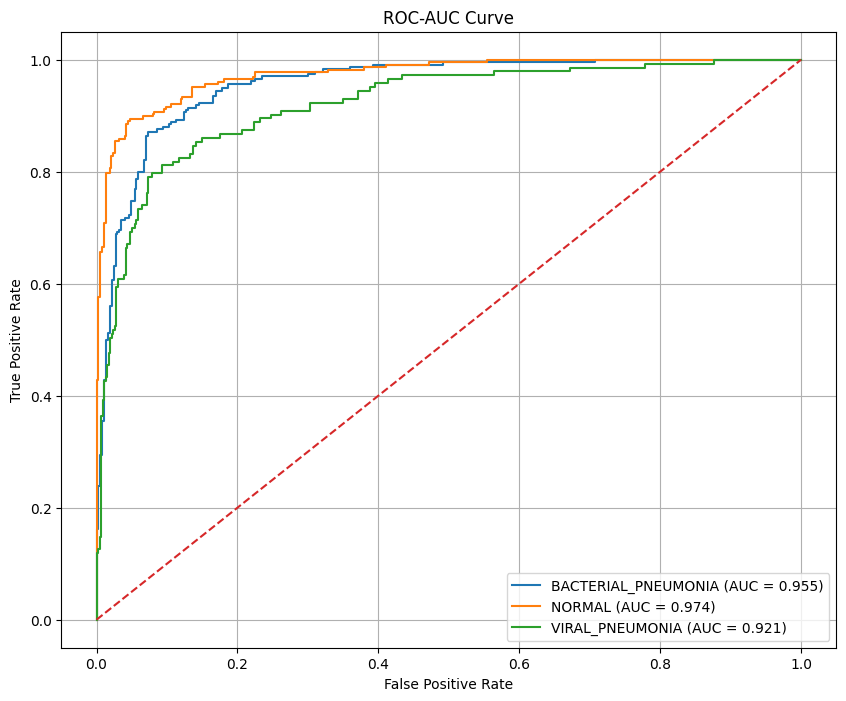

In [19]:
plt.figure(figsize=(10, 8))

for i in range(NUM_CLASSES):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{prep.train_dataset.classes[i]} "
              f"(AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve")

plt.legend()
plt.grid()

plt.show()

In [20]:
overall_auc = roc_auc_score(
    labels_bin,
    probs,
    multi_class='ovr'
)

print(f"\nOverall ROC-AUC Score: {overall_auc:.4f}")


Overall ROC-AUC Score: 0.9499


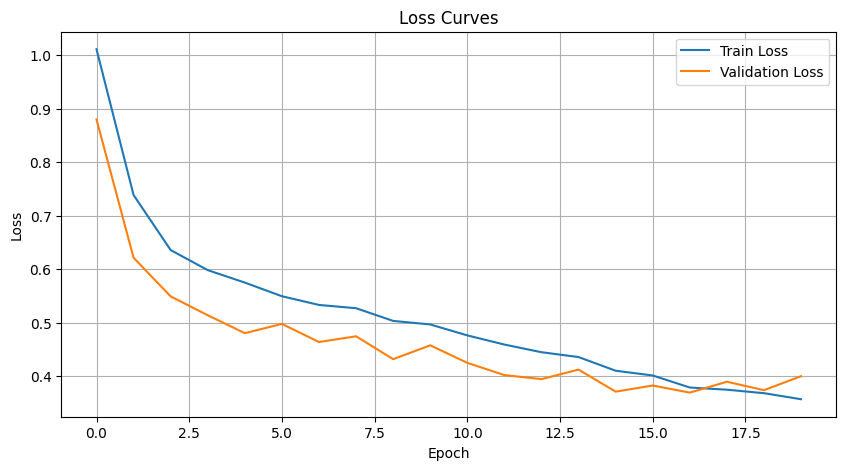

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curves")
plt.legend()
plt.grid()

plt.show()

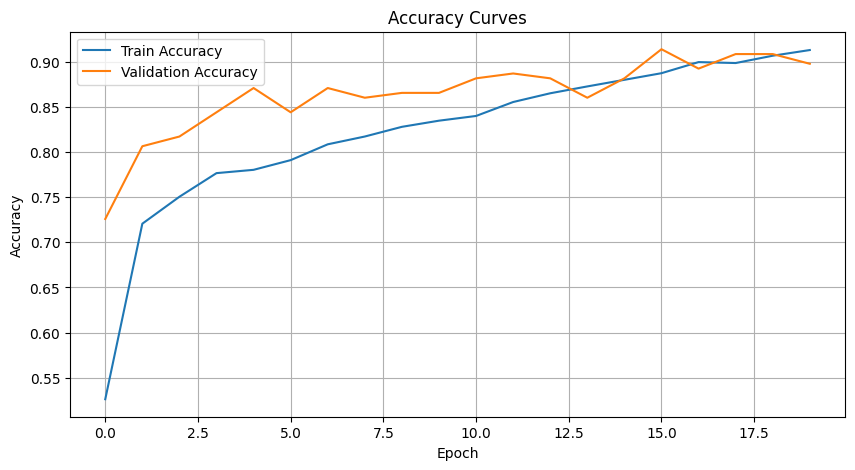

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy Curves")
plt.legend()
plt.grid()

plt.show()